In [1]:
import pandas as pd
import zipfile
import matplotlib.pyplot as plt

In [14]:
zf = zipfile.ZipFile('/home/vietha/MOIC/MOIC_Inventory/data/raw/m5-forecasting-accuracy.zip')

sales_val = pd.read_csv(zf.open('sales_train_validation.csv'))
calendar_val = pd.read_csv(zf.open('calendar.csv'))
sell_prices_val = pd.read_csv(zf.open('sell_prices.csv'))

In [15]:
#In ra các store riêng biệt trong dữ liệu sales_val
print(sales_val['store_id'].unique())

<StringArray>
['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2',
 'WI_3']
Length: 10, dtype: str


Co gọn xuống chỉ còn 1 store CA_3

In [16]:
# Filter xuống chỉ còn store CA_3
sales_ca3 = sales_val[sales_val['store_id'] == 'CA_3'].copy()
sales_ca3.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
6098,HOBBIES_1_001_CA_3_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_3,CA,0,0,0,0,...,0,2,4,0,1,1,1,0,3,3
6099,HOBBIES_1_002_CA_3_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_3,CA,0,0,0,0,...,0,0,0,2,0,0,0,0,1,0
6100,HOBBIES_1_003_CA_3_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_3,CA,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
6101,HOBBIES_1_004_CA_3_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_3,CA,0,0,0,0,...,2,7,10,15,3,0,3,4,12,3
6102,HOBBIES_1_005_CA_3_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_3,CA,0,0,0,0,...,0,3,5,1,2,0,0,0,5,1


Định dạng chuyển dữ liệu sales về dạng long và merge với bảng calendar

In [17]:
# Chuyển về dạng long format
sales_long = sales_ca3.melt(id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'], 
                             var_name='d', value_name='demand')

# Join với bảng calendar để lấy ra wm_yr_wk
sales_with_calendar = sales_long.merge(calendar_val[['d', 'wm_yr_wk', 'date']], on='d', how='left')

Join và tính doanh số của từng ngày 

In [18]:
# Join và lấy dữ liệu
sales_with_prices = sales_with_calendar.merge(
    sell_prices_val[['store_id', 'item_id', 'wm_yr_wk', 'sell_price']],
    on=['store_id', 'item_id', 'wm_yr_wk'],
    how='left'
)

# ensure column order: original sales_with_calendar columns followed by sell_price
sales_with_prices = sales_with_prices.loc[:, list(sales_with_calendar.columns) + ['sell_price']]

sales_with_prices['sell_price'] = sales_with_prices['sell_price'].fillna(0)
sales_with_prices['sales_amount'] = sales_with_prices['demand'] * sales_with_prices['sell_price']

sales_with_prices.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,demand,wm_yr_wk,date,sell_price,sales_amount
0,HOBBIES_1_001_CA_3_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_3,CA,d_1,0,11101,2011-01-29,0.0,0.0
1,HOBBIES_1_002_CA_3_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_3,CA,d_1,0,11101,2011-01-29,0.0,0.0
2,HOBBIES_1_003_CA_3_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_3,CA,d_1,0,11101,2011-01-29,0.0,0.0
3,HOBBIES_1_004_CA_3_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_3,CA,d_1,0,11101,2011-01-29,0.0,0.0
4,HOBBIES_1_005_CA_3_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_3,CA,d_1,0,11101,2011-01-29,0.0,0.0


Tính tổng sales amount trên từng item và phần loại cầu

In [19]:
import sys
import os

sys.path.append(os.path.abspath(".."))
from src.features.build_features import create_sales_by_item_with_classification


# Tổng doanh số (sales_amount) theo item_id và phân loại cầu
sales_by_item = create_sales_by_item_with_classification(sales_with_prices, product_colID='item_id', totalsales_col='sales_amount')

sales_by_item.head()

,item_id,sales_amount,ADI,CV2,demand_type
0,FOODS_3_120,442198.10,1.530400,0.283841,intermittent
1,FOODS_3_090,339060.48,1.231017,0.370897,smooth
2,FOODS_3_202,218819.78,1.060421,0.376163,smooth
3,FOODS_3_586,214319.58,1.002621,0.061261,smooth
4,FOODS_2_244,195579.76,1.047645,0.304107,smooth


Trực quan hoá các loại cầu

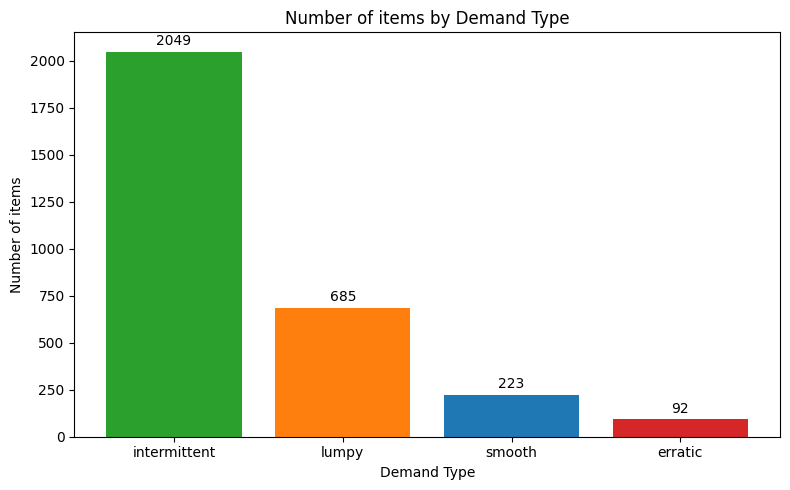

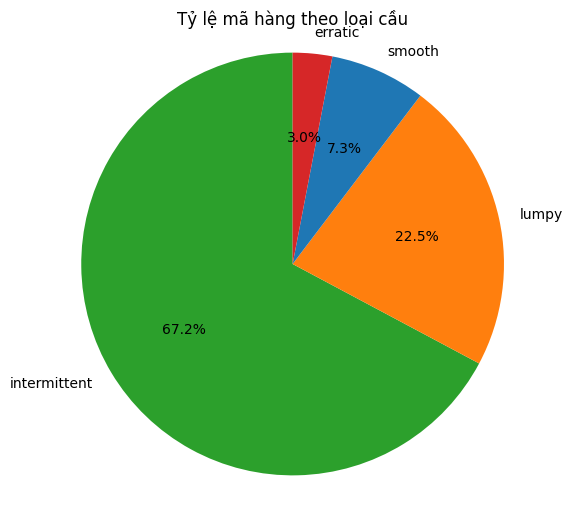

In [20]:
import matplotlib.pyplot as plt

# Đếm số lượng mã hàng theo demand_type (gộp NaN thành 'unknown')
demand_counts = sales_by_item['demand_type'].fillna('unknown').value_counts()

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(demand_counts.index, demand_counts.values, color=['tab:green', 'tab:orange', 'tab:blue', 'tab:red', 'gray'])
ax.set_title('Number of items by Demand Type')
ax.set_ylabel('Number of items')
ax.set_xlabel('Demand Type')

# Add value labels on bars
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + max(demand_counts.values) * 0.01, f'{int(h)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Pie chart (tỷ lệ)
fig2, ax2 = plt.subplots(figsize=(6, 6))
ax2.pie(demand_counts.values, labels=demand_counts.index, autopct='%1.1f%%', startangle=90,
        colors=['tab:green', 'tab:orange', 'tab:blue', 'tab:red', 'gray'])
ax2.set_title('Tỷ lệ mã hàng theo loại cầu')
ax2.axis('equal')
plt.show()

Thực hiện K-mean

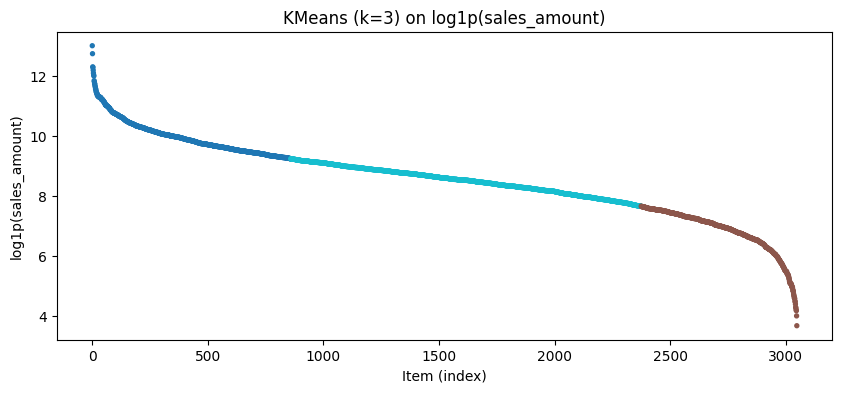

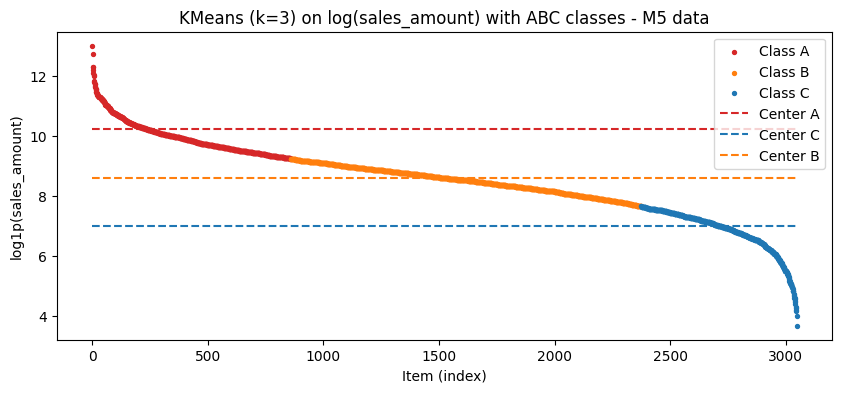

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from src.features.build_features import classify_abc_by_kmeans

# Apply K-means ABC classification
sales_by_item = classify_abc_by_kmeans(
    sales_by_item,
    sales_col='sales_amount',
    n_clusters=3,
    random_state=42
)

# Get cluster info for visualization
X_for_clust = np.log1p(sales_by_item['sales_amount'].values).reshape(-1, 1)
labels3 = sales_by_item['cluster_3'].values
abc_labels = sales_by_item['ABC_class'].values

# ---- Scatter plot log-sales theo cụm số ----
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(np.arange(len(sales_by_item)), X_for_clust.ravel(), c=labels3, cmap='tab10', s=8)
ax.set_xlabel('Item (index)')
ax.set_ylabel('log1p(sales_amount)')
ax.set_title('KMeans (k=3) on log1p(sales_amount)')

# --- Scatter plot log-sales theo ABC class ---
fig, ax = plt.subplots(figsize=(10, 4))

# Định nghĩa màu cho từng lớp
color_map = {'A': 'tab:red', 'B': 'tab:orange', 'C': 'tab:blue'}

# Vẽ từng lớp A/B/C riêng để có legend rõ ràng
x_idx = np.arange(len(sales_by_item))
for cls in ['A', 'B', 'C']:
    mask = (abc_labels == cls)
    ax.scatter(
        x_idx[mask],
        X_for_clust.ravel()[mask],
        s=8,
        label=f'Class {cls}',
        color=color_map[cls]
    )

ax.set_xlabel('Item (index)')
ax.set_ylabel('log1p(sales_amount)')
ax.set_title('KMeans (k=3) on log(sales_amount) with ABC classes - M5 data')

# Get centers for plotting
centers_log = np.log1p(sales_by_item.groupby('cluster_3')['sales_amount'].mean().values)
cluster_to_abc = {
    0: 'C' if sales_by_item[sales_by_item['cluster_3'] == 0]['sales_amount'].mean() < 
        sales_by_item[sales_by_item['cluster_3'] == 1]['sales_amount'].mean() else
    ('B' if sales_by_item[sales_by_item['cluster_3'] == 0]['sales_amount'].mean() <
        sales_by_item[sales_by_item['cluster_3'] == 2]['sales_amount'].mean() else 'A')
}

# Simpler approach: just get from existing ABC mapping
abc_by_cluster = sales_by_item.groupby('cluster_3')['ABC_class'].first().to_dict()
for clust_id, abc in abc_by_cluster.items():
    center_log = np.log1p(sales_by_item[sales_by_item['cluster_3'] == clust_id]['sales_amount'].mean())
    ax.hlines(
        center_log,
        xmin=0,
        xmax=len(sales_by_item) - 1,
        colors=color_map[abc],
        linestyles='--',
        label=f'Center {abc}'
    )

ax.legend()
plt.show()

In [22]:
sales_by_item

,item_id,sales_amount,ADI,CV2,demand_type,cluster_3,ABC_class
0,FOODS_3_120,442198.10,1.530400,0.283841,intermittent,0,A
1,FOODS_3_090,339060.48,1.231017,0.370897,smooth,0,A
2,FOODS_3_202,218819.78,1.060421,0.376163,smooth,0,A
3,FOODS_3_586,214319.58,1.002621,0.061261,smooth,0,A
4,FOODS_2_244,195579.76,1.047645,0.304107,smooth,0,A
...,...,...,...,...,...,...,...
3044,HOUSEHOLD_1_020,69.70,273.285714,0.260000,intermittent,1,C
3045,HOBBIES_2_047,65.82,18.219048,0.192017,intermittent,1,C
3046,HOUSEHOLD_1_512,63.58,70.851852,0.214533,intermittent,1,C
3047,HOBBIES_2_023,53.35,47.825000,0.203306,intermittent,1,C


In [23]:
from src.features.build_features import classify_product_lifecycle, get_current_lifecycle_stage

# Apply lifecycle classification directly on daily sales data
annual_sales = classify_product_lifecycle(
    sales_with_prices,
    item_col='item_id',
    date_col='date',
    sales_col='sales_amount'
)

print(annual_sales.head(5))

# Get current lifecycle stage as of 2015
current_stage_by_item = get_current_lifecycle_stage(
    annual_sales,
    year_col='year',
    item_col='item_id',
    as_of_year=2015
)

       item_id  year  annual_sales  pct_change  last_annual_sales  \
0  FOODS_1_001  2011        919.50         NaN                NaN   
1  FOODS_1_001  2012       1291.20   40.424144             919.50   
2  FOODS_1_001  2013        851.28  -34.070632            1291.20   
3  FOODS_1_001  2014        787.76   -7.461705             851.28   
4  FOODS_1_001  2015        810.88    2.934904             787.76   

   first_sales_year    life_cycle_stage  
0              2011        Introduction  
1              2011  Sustained maturity  
2              2011   Decaying maturity  
3              2011   Decaying maturity  
4              2011     Stable maturity  


<Axes: title={'center': 'Number of items by Life Cycle Stage (as of 2015)'}, xlabel='life_cycle_stage'>

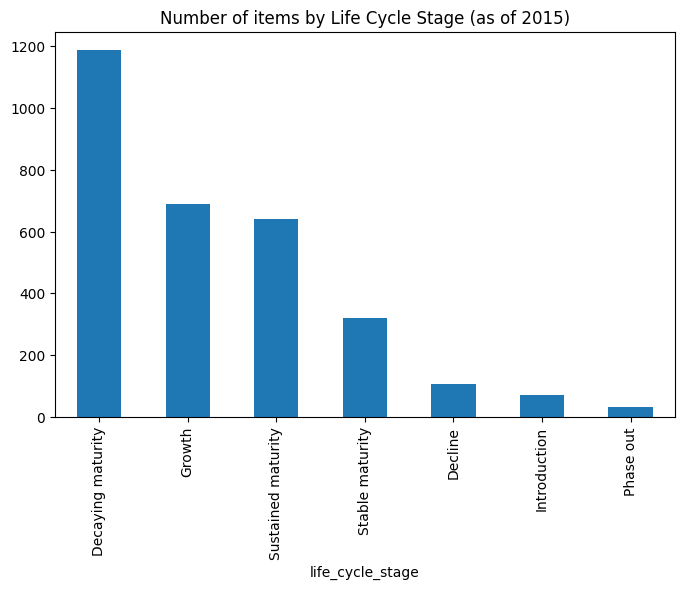

In [24]:
current_stage_by_item.value_counts('life_cycle_stage').plot(kind='bar', figsize=(8,5), title='Number of items by Life Cycle Stage (as of 2015)')

12504 11790


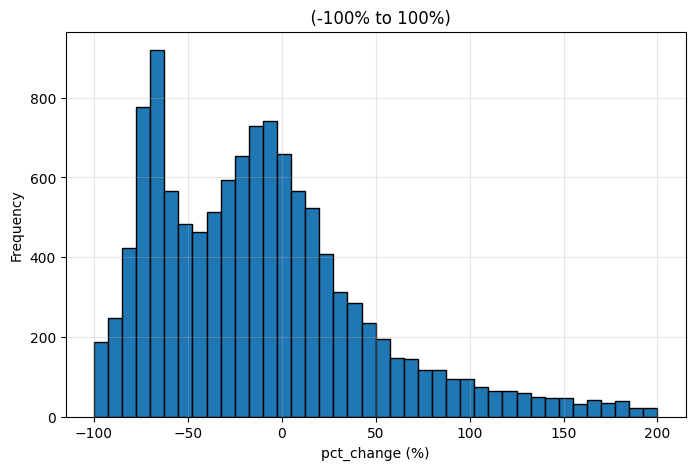

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Làm sạch pct_change
pct = (annual_sales['pct_change']
       .replace([np.inf, -np.inf], np.nan)
       .dropna())

# 2. Chỉ xem những quan sát trong khoảng -100% đến +100%
pct_clip = pct[pct.between(-200, 200)]

print(len(pct), len(pct_clip))  # xem còn bao nhiêu điểm sau khi cắt

plt.figure(figsize=(8, 5))
plt.hist(pct_clip, bins=40, edgecolor='black')  # 40 bins cho mượt
plt.xlabel('pct_change (%)')
plt.ylabel('Frequency')
plt.title('  (-100% to 100%)')
plt.grid(alpha=0.3)
plt.show()
